In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
from datetime import timedelta
import numpy as np
from utils import build_hourly_position_snapshots, liquidity_curve_on_ticks, build_hourly_lp_features, plot_missing_liquidity, compute_jit_liquidity, _prepare_non_nfpm_events, _prepare_hourly_blocks

In [2]:
hourly_blocks = pd.read_parquet('hourly_blocks.parquet')
df = pd.read_parquet('hourly_non_nfpm_mint_burn_events_full.parquet')
hourly_pool_state = pd.read_parquet('hourly_pool_state_full.parquet')
hourly_curve = pd.read_parquet('hourly_liquidity_full.parquet')

/home/jovyan/cloned_gits/onchain-insights/4.b Stablecoin liquidity ownership/utils.py:194: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  pos_mev_temp = pos_mev.query("block_number == @block_nbr")


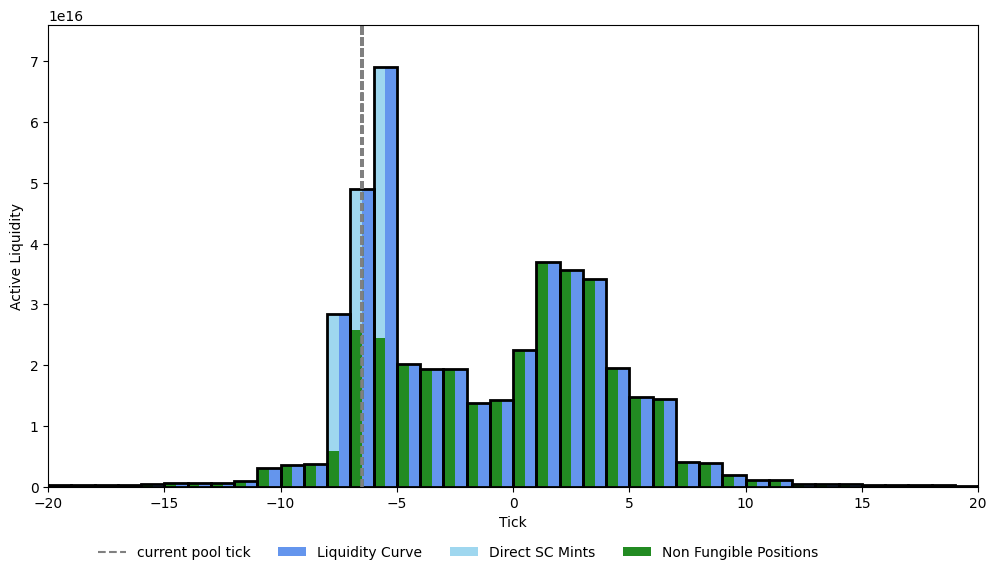

In [3]:
pos_mev = build_hourly_position_snapshots(df, hourly_blocks)
positions = pd.read_parquet('hourly_positions_full.parquet')
block_nbr = positions.block_number.unique()[-2]
plot_missing_liquidity(positions, pos_mev, hourly_curve, block_nbr, non_nfpm = True)

# Fraction of non-NFPM liquidity / JIT 

In [4]:
# Build your feature table.
df_hourly_features = build_hourly_lp_features(
    hourly_blocks=hourly_blocks,
    pool=hourly_pool_state,
    nfpm_positions=positions,
    non_nfpm_events=df,
    top_ks=(1, 5, 10),
    whale_top_pct=0.05,
    rolling_window_hours=24,
)

print(df_hourly_features.shape)
df_hourly_features.head()

(37570, 29)


,hour_utc,block_number,current_tick,pool_liquidity,nfpm_in_range_liquidity,non_nfpm_in_range_liquidity,total_in_range_liquidity,nfpm_in_range_share,non_nfpm_in_range_share,nfpm_owner_hhi,...,jit_mint_share,jit_total_share,whale_net_liquidity_flow,whale_mint_flow,whale_burn_flow,non_whale_net_liquidity_flow,non_whale_mint_flow,non_whale_burn_flow,whale_owner_count,tracked_owner_count
0,2022-01-01 00:00:00+00:00,13916166,-1.0,4.303942e+17,430393680261515917,5.540655e+11,430394234327008512.0,0.999999,0.000001,0.36576,...,0.000129,0.000003,252497725955883,10695919252747888,10443421526792005,0,0,0,3,70
1,2022-01-01 01:00:00+00:00,13916450,-1.0,4.303942e+17,430393680261515917,5.540655e+11,430394234327008512.0,0.999999,0.000001,0.36576,...,<NA>,0.0,0,0,0,0,0,0,3,70
2,2022-01-01 02:00:00+00:00,13916705,-1.0,4.282098e+17,428209237455805294,5.540655e+11,428209791521297920.0,0.999999,0.000001,0.369475,...,<NA>,0.0,0,0,0,0,0,0,3,70
3,2022-01-01 03:00:00+00:00,13916986,-1.0,4.282098e+17,428209237455805294,5.540655e+11,428209791521297920.0,0.999999,0.000001,0.369475,...,<NA>,0.0,0,0,0,0,0,0,3,70
4,2022-01-01 04:00:00+00:00,13917265,-1.0,4.282098e+17,428209237455805294,5.540655e+11,428209791521297920.0,0.999999,0.000001,0.369475,...,<NA>,0.0,0,0,0,0,0,0,3,70


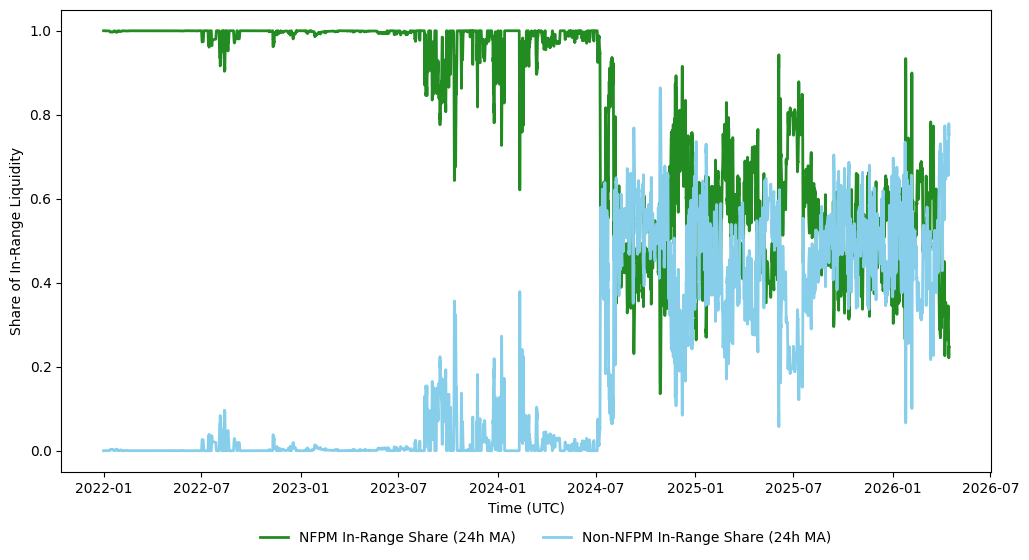

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df_hourly_features['hour_utc'], df_hourly_features['nfpm_in_range_share'].rolling(window=24, min_periods=1).mean(), label='NFPM In-Range Share (24h MA)', color = 'forestgreen', lw = 2)
plt.plot(df_hourly_features['hour_utc'], df_hourly_features['non_nfpm_in_range_share'].rolling(window=24, min_periods=1).mean(), label='Non-NFPM In-Range Share (24h MA)', color = 'skyblue', lw = 2)
# plt.title('Share of In-Range Liquidity from NFPM Positions Over Time')
plt.xlabel('Time (UTC)')
plt.ylabel('Share of In-Range Liquidity')
plt.legend(bbox_to_anchor=(.2, -0.1), loc='upper left', frameon=False, ncols = 2)
plt.savefig('nfpm_in_range_share_over_time.png', transparent = True, dpi = 300, bbox_inches = 'tight')

# JIT Liquidity Detection

**JIT (Just-In-Time) liquidity** = positions where a mint **and** burn happen in the **same block**.  
MEV bots add liquidity right before a swap and remove it right after, capturing fees with minimal risk.

In [6]:
jit_details.query('blockNumber == block_number')

NameError: name 'jit_details' is not defined

In [ ]:
# Drill down: showcase a specific JIT example
hb = _prepare_hourly_blocks(hourly_blocks)
ev = _prepare_non_nfpm_events(df)
_, jit_details = compute_jit_liquidity(ev, hb[["hour_utc", "block_number"]])

# Pick the block with the largest single JIT event
top_jit = jit_details.query('blockNumber == block_number').nlargest(1, "jit_liquidity").iloc[0]
example_block = int(top_jit["blockNumber"])
example_owner = top_jit["owner"]

# Get pool's total active liquidity at that hour for share computation
pool_liq_at_hour = df_hourly_features.loc[
    df_hourly_features["hour_utc"] == top_jit["hour_utc"], "pool_liquidity"
]
pool_liq = float(pool_liq_at_hour.iloc[0]) if len(pool_liq_at_hour) > 0 and "pool_liquidity" in df_hourly_features.columns else None

jit_share_of_active =  top_jit["jit_liquidity"] / ( top_jit['jit_liquidity'] + pool_liq )
jit_share_of_block_mint = top_jit["jit_liquidity"] / top_jit["block_total_minted"] * 100 if top_jit.get("block_total_minted", 0) > 0 else float("nan")

print(f"=== JIT Event ===")
print(f"Block:                     {example_block}")
print(f"Owner:                     {example_owner}")
print(f"Tick range:                [{int(top_jit['tickLower'])}, {int(top_jit['tickUpper'])})")
print(f"Minted liquidity:          {top_jit['mint_liq']:,.0f}")
print(f"Burned liquidity:          {top_jit['burn_liq']:,.0f}")
print(f"JIT liquidity:             {top_jit['jit_liquidity']:,.0f}")
print(f"Share of pool active liq:  {100*jit_share_of_active:.2f}%")
print(f"Share of block non-NFPM mints:      {jit_share_of_block_mint:.1f}%")
print(f"Sandwiched events (gap):   {int(top_jit['n_sandwiched_events'])} log-index slots between mint & burn")

# Show all events for this owner in that block
block_events = ev[
    (ev["blockNumber"] == example_block) & (ev["owner"] == example_owner)
].sort_values("logIndex")
block_events

In [ ]:
# JIT share of minted liquidity over time
fig, ax1 = plt.subplots(figsize=(12, 6))
plot_df = df_hourly_features.query('hour_utc > "2024-07-01 00:00:00+00:00"')
ax1.plot(
    plot_df['hour_utc'],
    plot_df['jit_mint_share'].rolling(window=24*7, min_periods=1).mean().fillna(0),
    label='JIT Share of Non-NFPM Minted Volume (7d MA)',
    color='tomato', lw=2
)
ax1.set_xlabel('Time (UTC)')
ax1.set_ylabel('Share')
ax1.legend(bbox_to_anchor=(.25, -0.1), loc='upper left', frameon=False, ncols=2)
plt.savefig('jit_share_over_time.png', transparent=True, dpi=300, bbox_inches='tight')

# 3CRV ownership graph

In [2]:
import json

df = pd.read_parquet('3CRV_lpevents.parquet')
with open('address_book.json') as f:
    data = json.load(f)
ad = pd.DataFrame(data, index = ['address_type']).T


In [3]:
ZERO = '0x0000000000000000000000000000000000000000'

# Compute net balance per address from all events
# Mints: to_address receives lp_amount (from 0x0)
# Burns: from_address loses lp_amount (to 0x0)
# Transfers: from sends, to receives — already captured by grouping on from/to

inflows = df.groupby('to_address')['lp_amount'].sum()
outflows = df.groupby('from_address')['lp_amount'].sum()

balances = inflows.subtract(outflows, fill_value=0)
balances = balances.drop(ZERO, errors='ignore')
balances = balances[balances > 1e-6]  # filter dust

total_supply = balances.sum()
print(f"Total 3CRV supply (from events): {total_supply:,.2f}")
print(f"Number of holders with balance > 0: {len(balances)}")
print(f"\nTop 20 holders:")
top = balances.sort_values(ascending=False).head(20)
for addr, bal in top.items():
    pct = bal / total_supply * 100
    print(f"  {addr}: {bal:>20,.2f}  ({pct:.2f}%)")
    
# Verified labels from Etherscan (checked 2026-04-02)
# Source: Etherscan name tags, ERC-20 tracker names, creator labels
KNOWN_LABELS = {
    '0xbfcf63294ad7105dea65aa58f8ae5be2d9d0952a': 'Curve 3pool\nGauge',           # Creator: Curve Deployer 2; txns labelled "Curve: DAI/USDC/USDT Gauge"
    '0xe74b28c2eae8679e3ccc3a94d5d0de83ccb84705': 'Wintermute\nExploiter',         # EOA funded via Tornado.Cash; Etherscan tag "Wintermute Exploiter"
    '0xed279fdd11ca84beef15af5d39bb4d4bee23f0ca': 'Curve\nLUSD3CRV-f Pool',        # ERC-20 tracker: "Curve.fi Factory... (LUSD3CR...)"
    '0x1402c1caa002354fc2c4a4cd2b4045a5b9625ef3': 'Gro Protocol\n3CRV Vault',      # ERC-20 tracker: "Gro 3Crv Vault (gro3Crv)"
    '0xa464e6dcda8ac41e03616f95f4bc98a13b8922dc': 'Curve\nFee Distributor',         # Txns labelled "Curve: Fee Distributor"
    '0x5a6a4d54456819380173272a5e8e9b9904bdf41b': 'Curve\nMIM-3LP3CRV-f',          # Creator: Abracadabra.money Deployer 3; Etherscan "Curve: MIM-3LP3CRV-f Token"
    '0xc5bddf9843308380375a611c18b50fb9341f502a': 'Yearn\nyveCRV-DAO',              # ERC-20 tracker: "veCRV-DAO yVault (yveCRV-...)"; Etherscan "Yearn: yveCRV-DAO Vault"
    '0x4f062658eaaf2c1ccf8c8e36d6824cdf41167956': 'Curve\nGUSD Pool',              # Txns labelled "Curve: GUSD Pool"
    # 0x52e1...d642 and 0x4486...8fde are unlabeled EOAs (whales)
}

def short_label(addr):
    if addr in KNOWN_LABELS:
        return KNOWN_LABELS[addr]
    return addr[:6] + '...' + addr[-4:]

# Check labels against top holders
for addr, bal in balances.sort_values(ascending=False).head(15).items():
    pct = bal / total_supply * 100
    print(f"  {short_label(addr):25s} {bal:>18,.0f} 3CRV  ({pct:.1f}%)")

Total 3CRV supply (from events): 157,385,226.38
Number of holders with balance > 0: 7552

Top 20 holders:
  0xe74b28c2eae8679e3ccc3a94d5d0de83ccb84705:       111,953,508.96  (71.13%)
  0xbfcf63294ad7105dea65aa58f8ae5be2d9d0952a:        21,566,562.67  (13.70%)
  0xed279fdd11ca84beef15af5d39bb4d4bee23f0ca:         7,384,011.29  (4.69%)
  0xa79828df1850e8a3a3064576f380d90aecdd3359:         2,235,571.10  (1.42%)
  0x1402c1caa002354fc2c4a4cd2b4045a5b9625ef3:         2,011,160.74  (1.28%)
  0xa464e6dcda8ac41e03616f95f4bc98a13b8922dc:         1,618,669.54  (1.03%)
  0xc5bddf9843308380375a611c18b50fb9341f502a:         1,047,940.54  (0.67%)
  0x52e1d37d4fb26e125f49c5255d6bd9b0ee27d642:           920,054.02  (0.58%)
  0x4f062658eaaf2c1ccf8c8e36d6824cdf41167956:           892,551.96  (0.57%)
  0x4486083589a063ddef47ee2e4467b5236c508fde:           891,699.17  (0.57%)
  0xa000016d11e045500240e2dfb9938c226e8a873c:           812,380.35  (0.52%)
  0xbcb91e689114b9cc865ad7871845c95241df4105:           

Showing 48 holders (>= 0.01% of supply)
Graph: 48 nodes, 89 edges


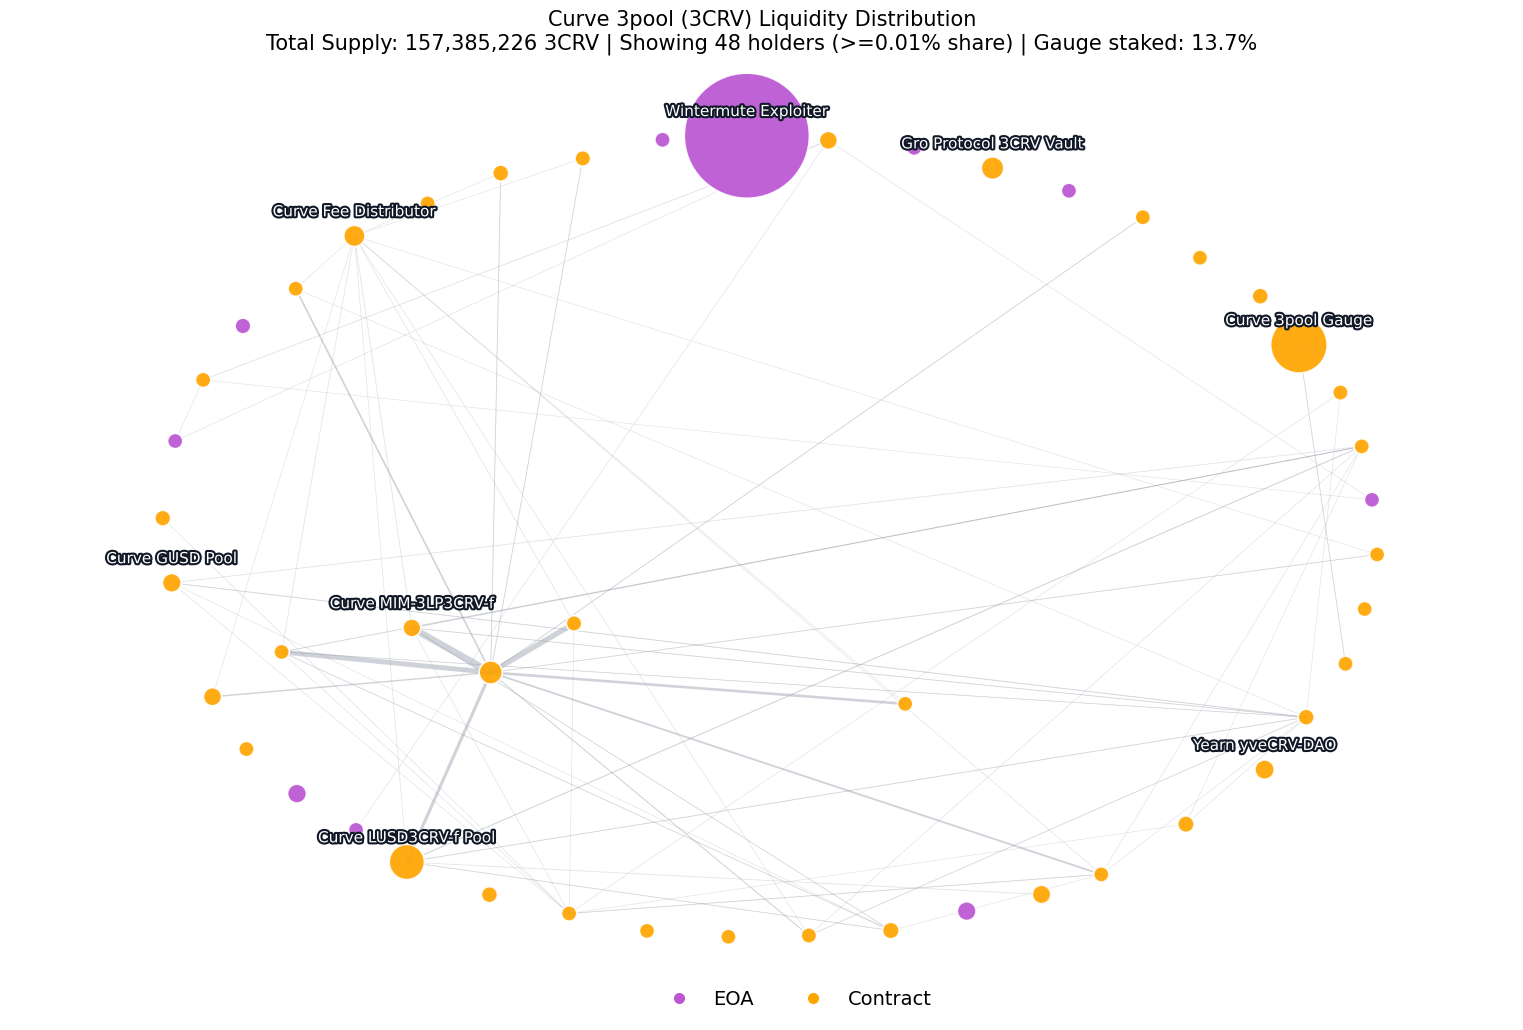

In [4]:
import math
import networkx as nx
import matplotlib.patheffects as pe
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

# Parameters
MIN_BALANCE_PCT = 0.01   # only show holders with >= 0.05% of supply
MIN_EDGE_PCT = 0.0      # only show transfer edges >= 0.01% of supply
SPRING_K_SCALE = 6000      # larger-than-default spacing, then rescaled for plotting

GAUGE_ADDR = '0xbfcf63294ad7105dea65aa58f8ae5be2d9d0952a'

def get_address_type(addr):
    value = data.get(addr, 'unknown')
    if isinstance(value, dict):
        return value.get('address_type', 'unknown')
    return value

# Filter to top holders
top_holders = balances[balances / total_supply * 100 >= MIN_BALANCE_PCT].sort_values(ascending=False)
print(f"Showing {len(top_holders)} holders (>= {MIN_BALANCE_PCT}% of supply)")
top_set = set(top_holders.index)

# Build transfer graph among top holders
transfers_df = df[df['category'] == 'transfer']
transfer_agg = transfers_df.groupby(['from_address', 'to_address'])['lp_amount'].sum().reset_index()

G = nx.DiGraph()

for addr in top_holders.index:
    bal = top_holders[addr]
    addr_type = get_address_type(addr)
    G.add_node(
        addr,
        balance=bal,
        pct=bal / total_supply * 100,
        label=KNOWN_LABELS.get(addr, short_label(addr)),
        address_type=addr_type,
    )

for _, row in transfer_agg.iterrows():
    src, dst, amt = row['from_address'], row['to_address'], row['lp_amount']
    if src in top_set and dst in top_set and amt / total_supply * 100 >= MIN_EDGE_PCT:
        G.add_edge(src, dst, weight=amt)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

layout_k = SPRING_K_SCALE 
pos = nx.spring_layout(
    G,
    k=layout_k,
    iterations=500,
    seed=42,
)
# pos = layout_with_isolates(G, core_scale=0.9, isolate_radius=1.35)
pos = nx.rescale_layout_dict(pos, scale=1.0)

fig, ax = plt.subplots(figsize=(16, 11))

edges = list(G.edges(data=True))
if edges:
    max_edge_weight = max(edge_data['weight'] for _, _, edge_data in edges)
    edge_segments = [(pos[u], pos[v]) for u, v, _ in edges]
    edge_widths = [0.5 + 4.5 * math.sqrt(edge_data['weight'] / max_edge_weight) for _, _, edge_data in edges]
    edge_collection = LineCollection(
        edge_segments,
        colors=[(156 / 255, 163 / 255, 175 / 255, 0.28)],
        linewidths=edge_widths,
        zorder=1,
    )
    ax.add_collection(edge_collection)

node_order = list(G.nodes())
node_xy = [pos[addr] for addr in node_order]
node_sizes = []
node_colors = []
known_labels = {}
has_unknown_type = False

max_bal = top_holders.max()
for addr in node_order:
    node_data = G.nodes[addr]
    balance = node_data['balance']
    address_type = node_data['address_type']
    node_sizes.append(120 + 8000 * (balance / max_bal))

    if address_type == 'contract':
        color = "orange"
    elif address_type == 'eoa':
        color = 'mediumorchid'
    else:
        color = '#9ca3af'
        has_unknown_type = True
    node_colors.append(color)

    if addr in KNOWN_LABELS:
        known_labels[addr] = KNOWN_LABELS[addr].replace('\n', ' ')

ax.scatter(
    [xy[0] for xy in node_xy],
    [xy[1] for xy in node_xy],
    s=node_sizes,
    c=node_colors,
    alpha=0.92,
    edgecolors='white',
    linewidths=1.25,
    zorder=2,
)

for addr, label in known_labels.items():
    x, y = pos[addr]
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(0, 12),
        textcoords='offset points',
        fontsize=11,
        color='white',
        ha='center',
        va='bottom',
        zorder=3,
        path_effects=[pe.withStroke(linewidth=3, foreground='#111827')],
    )

legend_handles = [
    Line2D([0], [0], marker='o', color='none', label='EOA', markerfacecolor='mediumorchid', markeredgecolor='white', markersize=9),
    Line2D([0], [0], marker='o', color='none', label='Contract', markerfacecolor='orange', markeredgecolor='white', markersize=9),
]
if has_unknown_type:
    legend_handles.append(
        Line2D([0], [0], marker='o', color='none', label='Unknown', markerfacecolor='#9ca3af', markeredgecolor='white', markersize=9)
    )

ax.legend(
    handles=legend_handles,
    loc='upper left',
    frameon=False,
    ncols = 2,
    fontsize=14,
    bbox_to_anchor=(0.42, 0.05),
    labelcolor='black',
)

gauge_pct = top_holders.get(GAUGE_ADDR, 0) / total_supply * 100
ax.set_title(
    "Curve 3pool (3CRV) Liquidity Distribution\n"
    f"Total Supply: {total_supply:,.0f} 3CRV | "
    f"Showing {len(top_holders)} holders (>={MIN_BALANCE_PCT}% share) | "
    f"Gauge staked: {gauge_pct:.1f}%",
    color='black',
    fontsize=15,
    pad=18,
)

ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.15, 1.15)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.subplots_adjust(left=0.03, right=0.97, top=0.9, bottom=0.04)
plt.savefig('3CRV_liquidity_distribution.png', dpi=300, transparent=True, bbox_inches = 'tight')